# In-class Assignment 6.2

**Week 6 Wednesday**

#### &#x2705; Owen Sliger, Colby Hutchinson, Alex Munoz, Lewis Heck

Today, we continue using the modeling cycle.

- **(1)** Pose a question of a real-world physics phenomena.
- **(2a)** Make assumptions about the phenomenon to simplify it into a form that balances two priorities: addressing the core of the question and creating a computational model of the phenomenon.
- **(2b)** Review the resources you have that might be useful for creating a model to answer the question, including: computing/programming tools, physics concepts, numerical methods, existing models.
- **(3a)** Make a plan for creating or refining a computational model, and design tests to validate its effectiveness at answering the question.
- **(3b)** Create or refine a new computational model using your resources and the shared expertise of your group, stepping back to critique and update your plan as needed.
- **(4)** Test the effectiveness of your model using your planned validation process.

---

## Part 1: Verifying a working model

An example of a question and a model for answering it could be:

**How do the frequencies of the plucked guitar note compare to the plucked banjo note?**

And the computational model could involve code somewhat like this:

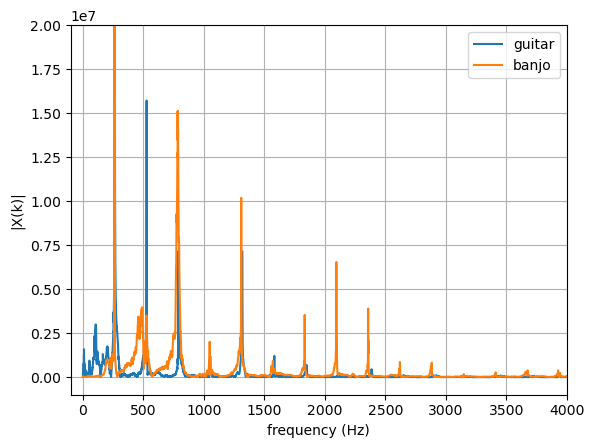

In [2]:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt

# 
rate_g, amp_g = wav.read("../../hub_data_share/data/guitar-mono.wav")
rate_b, amp_b = wav.read("../../hub_data_share/data/banjo-mono.wav")

# 
T_g = len(amp_g) / rate_g
T_b = len(amp_b) / rate_b

# 
Xk_g = np.fft.fft(amp_g)
Xk_b = np.fft.fft(amp_b)

# 
freq_g = np.arange(len(Xk_g)) / T_g
freq_b = np.arange(len(Xk_b)) / T_b

# 
plt.plot(freq_g, np.abs(Xk_g), label="guitar")
plt.plot(freq_b, np.abs(Xk_b), label="banjo")
# 
plt.xlabel("frequency (Hz)")
plt.ylabel("|X(k)|")
# 
plt.xlim(-100, 4000)
plt.ylim(-1e6, 2e7)
# 
plt.legend()
plt.grid()
plt.show()

To verify this model answers the question, you can notice differences between intensities of frequency peaks, combinations of different frequency peaks across each instrument, and other differences between the two frequency distributions.

You can even use an inverse FFT to bring a frequency distribution back into its amplitudes, and play the audio out loud:

In [3]:
from IPython.display import Audio

# 
ifft_amp_g = np.fft.ifft(Xk_g)

# 
Audio(ifft_amp_g, rate=rate_g)

/opt/conda/lib/python3.12/site-packages/IPython/lib/display.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  data = np.array(data, dtype=float)


&#x2705; Your group might have different code than above. Bring your computational model from ICA 6.1 into this notebook. 

&#x2705; You are also welcome to use the above code for today's assignment if your group agrees on doing this and takes the time to go through and **explain what each part of the code is doing by filling in the empty comments.**

&#x2705; - Guitar has less pronounced spikes than the banjo
         - Guitar has one major spike that is 4x the next larger one at ~260 Hz, while the banjo has many more spikes that are more even in magnitude
         - They do have the same, or very similar, intervals between Cn spikes.
         - Banjo has more 'noise' than the guitar.
         - the guitars Cn spikes have less width, or frequency spill over, than the banjo

---

## Part 2: Using a working model

At the end of the modeling cycle we have Step 4: Test the effectiveness of your model using your planned validation process.

This is what you did above in Part 1.

From here, we can return to Step 1: Pose a question of a real-world physics phenomena.

However, we do not have to immediately try to push the boundaries of our model and force ourselves to refine our model further (that would entail continuing on to Step 2 and 3). Instead, we can use our model to see what else it can enable us to investigate. There are many questions we could answer without needing to reinitiate the modeling cycle.

You now have the tools you need to translate back from a frequency distribution to an audio sample. You can even test out some of the comparisons you made at the end of Part 1. For example, *does the banjo twang really come from those high-frequency peaks?*

&#x2705; Today, use your model of the frequency distributions to investigate new questions. You can edit the existing frequencies however you like, and test your changes through plotting, listening to the resulting audio, or any other method your group comes up with.

To test the model, we will recreate the sound of both instruments using a manual inverse fourier transform that pretends that the most influential Cn are the ones that are included. This will get rid of the noise and test that the spikes and their amplitudes are what influence the sound more than the width of the spikes.